# Portfolioaufgabe: Datenanalyse – Financial Fraud Dataset

**Datensatz:** Financial Fraud Detection Dataset  
**Thema:** Erkennung betrügerischer Transaktionen im Finanzbereich

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

from src.config import CLEAN_TRANSACTIONS_PATH

# Plot-Stil
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 1. Business-Fragestellungen

Mit diesem Datensatz lassen sich folgende praxisrelevante Fragen beantworten:

1. **Wie hoch ist die Betrugsrate im Datensatz?** 10 % der Transaktionen (500 von 5.000) sind betrügerisch – die Klassen sind mit 90/10 klar unbalanciert.
2. **Wie unterscheiden sich Transaktionsbeträge zwischen legitimen und betrügerischen Transaktionen?** Betrugstransaktionen haben einen Durchschnittsbetrag von ~5.853 €, legitime Transaktionen nur ~124 € – ein Faktor von fast 50.
3. **Welche Zahlungsmethoden werden am häufigsten genutzt und welche weisen die höchste Betrugsrate auf?** DebitCard ist die häufigste Methode (n=2.169), MobileWallet hat mit 30,9 % die höchste Betrugsrate gegenüber 3,5 % bei DebitCard.
4. **In welchen Händlerkategorien treten Betrugsfälle am häufigsten auf?** Cryptocurrency und Gaming weisen hohe Betrugsraten auf, Grocery und Retail nahezu 0 %.
5. **Wie verteilt sich der Kontostand zwischen betrügerischen und legitimen Kunden?** Betrugskunden haben im Schnitt ~1.560 € Kontostand, legitime Kunden ~7.706 €.
6. **Wie viele fehlgeschlagene Transaktionen haben Betrugskunden im Vergleich zu legitimen Kunden?** Betrugskunden: Ø 2,66 Fehlversuche, legitime Kunden: Ø 0,35 – ab ≥3 Fehlversuchen liegt die Betrugsrate bei 100 %.

---
## 2. SMART-Zielsetzung

**S**pecific: Entwicklung eines datengetriebenen Analysemodells zur Erkennung betrügerischer Finanztransaktionen auf Basis des vorhandenen Datensatzes.

**M**easurable: Ziel ist eine AUC-ROC ≥ 0,80 sowie die Identifikation der Top-3-Einflussfaktoren.

**A**chievable: 5.000 Transaktionen mit 11 Variablen, 10 % Betrugsrate.

**R**elevant: Alle eingesetzten Methoden (deskriptive Analyse, Drill-Down, K-Means, hierarchisches Clustering, logistische Regression) entsprechen dem Standard der Betrugserkennung im Finanzsektor.

**T**ime-bound: Abschluss im Rahmen dieser Portfolioaufgabe.

---
## 3. Deskriptive & Diagnostische Datenanalyse

### 3.1 Datenverständnis

In [6]:
df = pd.read_csv(CLEAN_TRANSACTIONS_PATH)

print(f"Datensatzgröße: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print()
print("Datentypen der Variablen:")
print(df.dtypes)

Datensatzgröße: 5000 Zeilen, 11 Spalten

Datentypen der Variablen:
TransactionID                      str
CustomerID                         str
TransactionLocation                str
TransactionTime                    str
TransactionAmount              float64
PaymentMethod                      str
MerchantCategory                   str
FailedTransactionsLast7Days      int64
AccountBalance                 float64
AuthenticationMethod               str
FraudLabel                       int64
dtype: object


**Überblick über die Variablen:**

| Variable | Typ | Bedeutung |
|---|---|---|
| TransactionID | Kategorisch (ID) | Eindeutige Transaktions-ID |
| CustomerID | Kategorisch (ID) | Eindeutige Kunden-ID |
| TransactionLocation | Kategorisch | Stadt/Ort der Transaktion |
| TransactionTime | Kategorisch (Zeit) | Uhrzeit der Transaktion |
| TransactionAmount | Numerisch (float) | Transaktionsbetrag in EUR |
| PaymentMethod | Kategorisch | Zahlungsmethode |
| MerchantCategory | Kategorisch | Händlerkategorie |
| FailedTransactionsLast7Days | Numerisch (int) | Fehlgeschlagene Transaktionen (letzte 7 Tage) |
| AccountBalance | Numerisch (float) | Aktueller Kontostand |
| AuthenticationMethod | Kategorisch | Authentifizierungsmethode |
| FraudLabel | Binär (0/1) | Zielvariable: 1 = Betrug, 0 = legitim |

Der Datensatz enthält drei numerische Variablen, eine binäre Zielvariable sowie sieben kategorische Variablen. Die IDs (TransactionID, CustomerID) und TransactionTime sind für die Analyse nicht direkt relevant und werden nicht modelliert.

### 3.2 Erste Datenexploration

In [7]:
# Erste 10 Zeilen
df.head(10)

,TransactionID,CustomerID,TransactionLocation,TransactionTime,TransactionAmount,PaymentMethod,MerchantCategory,FailedTransactionsLast7Days,AccountBalance,AuthenticationMethod,FraudLabel
0,TX001502,CU36277,München,09:07:19,204.46,DebitCard,Grocery,1,9412.07,TwoFactor,0
1,TX002587,CU96385,Berlin,10:57:59,35.69,CreditCard,Retail,0,12397.87,Biometric,0
2,TX002654,CU66225,Berlin,10:04:02,15.62,BankTransfer,Grocery,0,12375.17,Biometric,0
3,TX001056,CU38910,München,15:22:57,139.88,CreditCard,Retail,0,12120.74,PasswordOnly,0
4,TX000706,CU46050,Lagos,08:42:04,50.33,DebitCard,Grocery,0,12497.18,Biometric,0
5,TX000107,CU67134,München,20:57:50,89.17,BankTransfer,Grocery,0,14900.78,Biometric,0
6,TX000590,CU66055,Berlin,15:12:46,185.73,DebitCard,Restaurant,0,5748.55,Biometric,0
7,TX002469,CU12759,München,08:21:20,27.63,CreditCard,Grocery,0,12600.12,TwoFactor,0
8,TX002414,CU55909,Berlin,16:03:04,56.59,DebitCard,Grocery,0,14893.07,TwoFactor,0
9,TX001601,CU33400,Berlin,22:47:50,57.43,DebitCard,Grocery,0,10172.59,Biometric,0


In [8]:
print(f"Zeilen: {df.shape[0]}, Spalten: {df.shape[1]}")
print()
print("Spaltennamen:")
print(df.columns.tolist())

Zeilen: 5000, Spalten: 11

Spaltennamen:
['TransactionID', 'CustomerID', 'TransactionLocation', 'TransactionTime', 'TransactionAmount', 'PaymentMethod', 'MerchantCategory', 'FailedTransactionsLast7Days', 'AccountBalance', 'AuthenticationMethod', 'FraudLabel']


In [9]:
# Statistische Übersicht – mögliche Ausreißer erkennbar
df.describe()

,TransactionAmount,FailedTransactionsLast7Days,AccountBalance,FraudLabel
count,5000.000000,5000.00000,5000.000000,5000.00000
mean,570.538934,0.58380,7214.602828,0.10000
std,1675.907811,0.97835,4358.222469,0.30003
min,5.000000,0.00000,104.940000,0.00000
25%,71.842500,0.00000,3145.720000,0.00000
50%,128.100000,0.00000,7024.295000,0.00000
75%,193.415000,1.00000,10994.210000,0.00000
max,9989.440000,4.00000,14996.120000,1.00000


**Beobachtungen aus df.describe():**

- **TransactionAmount**: Mittelwert (571 €) liegt weit über dem Median (128 €) – extreme Rechtsschiefe (Skewness ~3,9). 75 % aller Transaktionen liegen unter 193 €, das Maximum bei 9.989 €. Die hohen Werte gehören fast ausschließlich zu Betrugsfällen.
- **FailedTransactionsLast7Days**: Median = 0, Mittelwert = 0,58, Maximum = 4. Die Variable ist hochgradig auf 0 konzentriert. Werte ≥3 treten nahezu ausschließlich bei Betrug auf.
- **AccountBalance**: Mittelwert (7.215 €) und Median (7.024 €) liegen eng beieinander – annähernd symmetrisch verteilt, keine Ausreißer. Betrugsfälle weisen jedoch systematisch niedrigere Kontostände auf (Ø ~1.560 €).
- **Potenzielle Ausreißer**: `TransactionAmount` (403, 8,1 %) und `FailedTransactionsLast7Days` (343, 6,9 %) – beide inhaltlich bedeutsam, nicht zu entfernen.

### 3.3 Deskriptive Kennzahlen

In [50]:
num_cols = ['TransactionAmount', 'FailedTransactionsLast7Days', 'AccountBalance']

stats_df = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats_df.columns = ['Mittelwert', 'Median', 'Standardabweichung', 'Minimum', 'Maximum']
stats_df.round(2)

,Mittelwert,Median,Standardabweichung,Minimum,Maximum
TransactionAmount,570.54,128.1,1675.91,5.00,9989.44
FailedTransactionsLast7Days,0.58,0.0,0.98,0.00,4.00
AccountBalance,7214.60,7024.3,4358.22,104.94,14996.12


> **Interpretation der deskriptiven Kennzahlen:**
>
> `TransactionAmount` zeigt mit Standardabweichung 1.676 € bei einem Median von 128 € eine extreme rechtsschiefe Streuung – vollständig getrieben durch die Betrugsfälle im Hochbetragssegment. `FailedTransactionsLast7Days` wirkt trotz kleiner Standardabweichung (0,98) als scharfer Schwellenwert-Indikator: Betrugskunden haben im Schnitt 2,66 Fehlversuche, legitime Kunden 0,35. `AccountBalance` ist die einzige symmetrisch verteilte Variable – sie fungiert als passiver Schutzfaktor: hoher Kontostand korreliert negativ mit Betrug.

### 3.4 Verteilungen und Visualisierungen

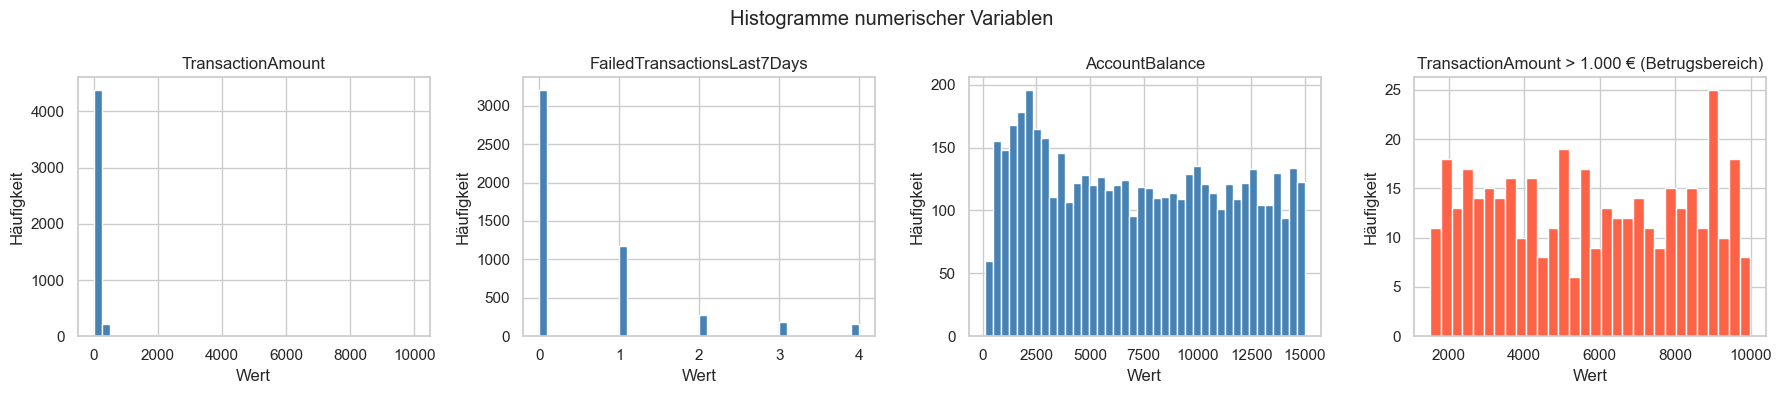

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes[:3], num_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Wert')
    ax.set_ylabel('Häufigkeit')

# Zoom auf TransactionAmount > 1000 (Betrugsbereich)
axes[3].hist(df[df['TransactionAmount'] > 1000]['TransactionAmount'],
             bins=30, color='tomato', edgecolor='white')
axes[3].set_title('TransactionAmount > 1.000 € (Betrugsbereich)')
axes[3].set_xlabel('Wert')
axes[3].set_ylabel('Häufigkeit')

plt.suptitle('Histogramme numerischer Variablen')
plt.tight_layout()
plt.show()

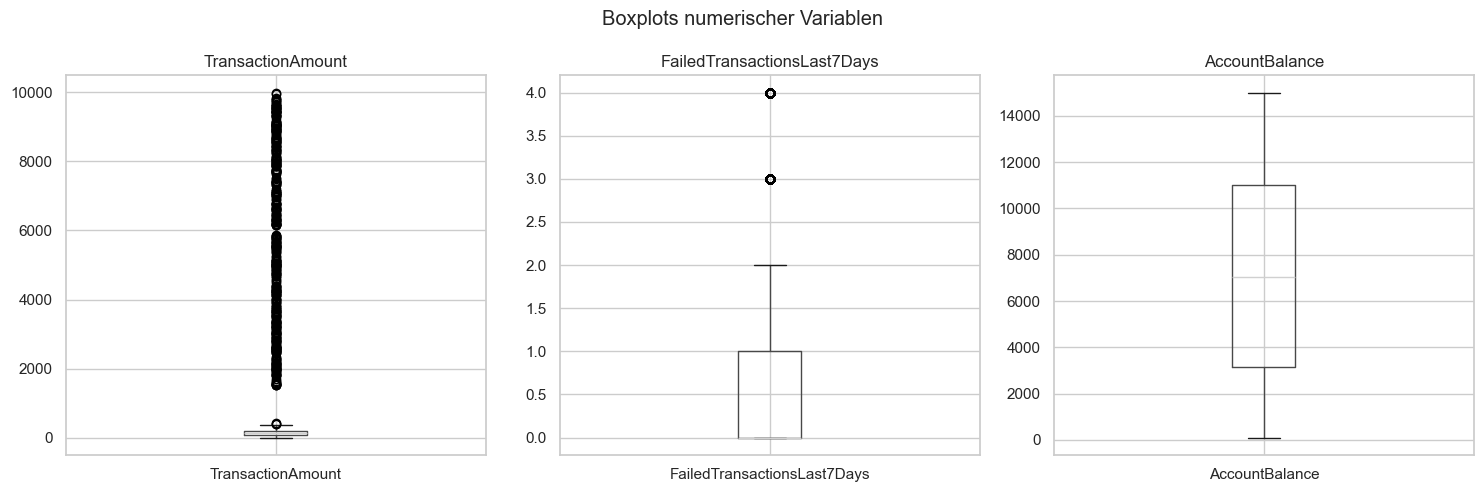

In [12]:
# Boxplots – Ausreißer und Verteilungsstreuung
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.suptitle('Boxplots numerischer Variablen')
plt.tight_layout()
plt.show()

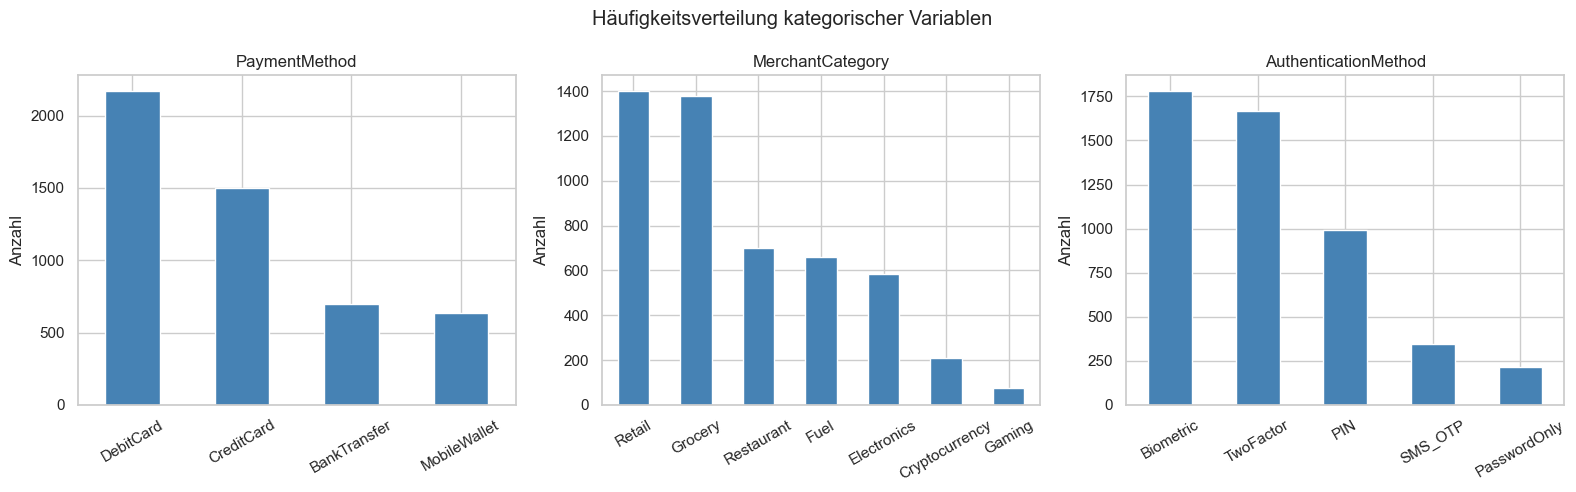

In [13]:
# Balkendiagramme für kategorische Variablen
cat_cols = ['PaymentMethod', 'MerchantCategory', 'AuthenticationMethod']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Anzahl')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Häufigkeitsverteilung kategorischer Variablen')
plt.tight_layout()
plt.show()

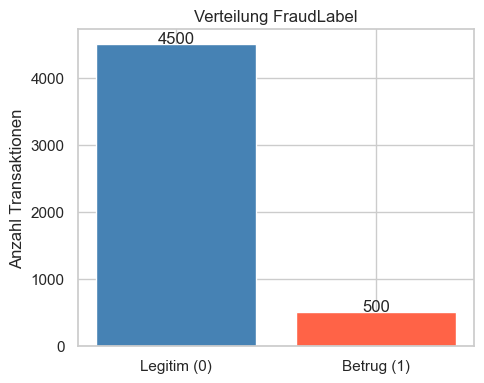

Betrugsrate: 10.0%


In [14]:
# Verteilung der Zielvariable FraudLabel
fraud_counts = df['FraudLabel'].value_counts()
labels = ['Legitim (0)', 'Betrug (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, fraud_counts.values, color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Verteilung FraudLabel')
plt.ylabel('Anzahl Transaktionen')
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"Betrugsrate: {fraud_counts[1] / len(df) * 100:.1f}%")

> **Erkenntnisse aus den Visualisierungen:**
>
> Die Histogramme zeigen die extreme Rechtsschiefe bei `TransactionAmount`: der Großteil der Transaktionen liegt unter 200 €, der separate Zoom-Plot macht den Betrugsbereich (> 1.000 €) als eigenständige Häufung sichtbar. `FailedTransactionsLast7Days` ist nahezu ausschließlich auf 0 konzentriert; Werte ≥3 sind als separate Balken sichtbar und entsprechen fast vollständig Betrugsfällen.
>
> Die Balkendiagramme zeigen: **DebitCard** ist die häufigste Zahlungsmethode (n=2.169), **Retail** und **Grocery** dominieren bei den Händlerkategorien. **MobileWallet** (n=637) und **Cryptocurrency** (n=207) sind seltener, aber stark überrepräsentiert bei Betrug. Die Zielvariable ist mit 90/10 klar unbalanciert – AUC-ROC ist die geeignetere Güte-Metrik.

### 3.5 Datenqualität – Fehlende Werte, Duplikate & Ausreißer

In [15]:
# Fehlende Werte je Spalte
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Fehlend': missing, 'Anteil (%)': missing_pct})

,Fehlend,Anteil (%)
TransactionID,0,0.0
CustomerID,0,0.0
TransactionLocation,0,0.0
TransactionTime,0,0.0
TransactionAmount,0,0.0
PaymentMethod,0,0.0
MerchantCategory,0,0.0
FailedTransactionsLast7Days,0,0.0
AccountBalance,0,0.0
AuthenticationMethod,0,0.0


In [16]:
print(f"Anzahl Duplikate: {df.duplicated().sum()}")
print(f"Shape vor Bereinigung: {df.shape}")

df = df.drop_duplicates()

print(f"Shape nach Bereinigung: {df.shape}")

Anzahl Duplikate: 0
Shape vor Bereinigung: (5000, 11)
Shape nach Bereinigung: (5000, 11)


In [17]:
# Ausreißer-Erkennung via IQR für numerische Variablen
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} Ausreißer ({len(outliers)/len(df)*100:.1f}%)")

TransactionAmount: 403 Ausreißer (8.1%)
FailedTransactionsLast7Days: 343 Ausreißer (6.9%)
AccountBalance: 0 Ausreißer (0.0%)


> **Interpretation der Ausreißer:**
>
> `TransactionAmount` hat 403 Ausreißer (8,1 %) oberhalb der IQR-Grenze. Diese sind **kein Datenfehler** – der Betrag ist mit OR 36,2 der mit Abstand stärkste Prädiktor im Modell. Entfernen würde das wichtigste Betrugsindiz vernichten.
>
> `FailedTransactionsLast7Days` hat 343 Ausreißer (6,9 %) – exakt die Transaktionen mit ≥3 Fehlversuchen, die alle betrügerisch sind. Ebenfalls inhaltlich bedeutsam.
>
> `AccountBalance` hat keine Ausreißer. Beide identifizierten Ausreißergruppen werden **bewusst beibehalten**, da sie die Betrugssignatur des Datensatzes abbilden.

### 3.6 Drill-Down-Analyse

Eine Drill-Down-Analyse geht von einer übergeordneten Frage schrittweise in immer tiefere Detailebenen.  
Hier werden zwei solche Ketten durchgeführt.

#### Drill-Down 1: Wo tritt Betrug auf?

**Ebene 1:** Wie hoch ist die Betrugsrate insgesamt?

In [18]:
# Ebene 1: Gesamtbetrugsrate
overall_fraud_rate = df['FraudLabel'].mean()
print(f"Gesamte Betrugsrate: {overall_fraud_rate:.2%}")

Gesamte Betrugsrate: 10.00%


**Ebene 2:** Unterscheidet sich die Betrugsrate je nach Zahlungsmethode?

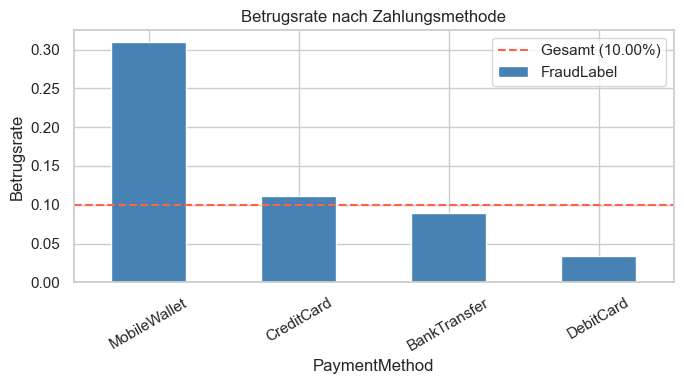

Auffälligste Zahlungsmethode: MobileWallet (30.93%)


In [19]:
# Ebene 2: Betrugsrate nach Zahlungsmethode
fraud_by_payment = df.groupby('PaymentMethod')['FraudLabel'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
fraud_by_payment.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(overall_fraud_rate, color='tomato', linestyle='--', label=f'Gesamt ({overall_fraud_rate:.2%})')
plt.title('Betrugsrate nach Zahlungsmethode')
plt.ylabel('Betrugsrate')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# Auffälligste Zahlungsmethode für nächste Ebene merken
highest_payment = fraud_by_payment.idxmax()
print(f"Auffälligste Zahlungsmethode: {highest_payment} ({fraud_by_payment.max():.2%})")

**Ebene 3:** Bei der auffälligsten Zahlungsmethode – in welchen Händlerkategorien konzentriert sich der Betrug?

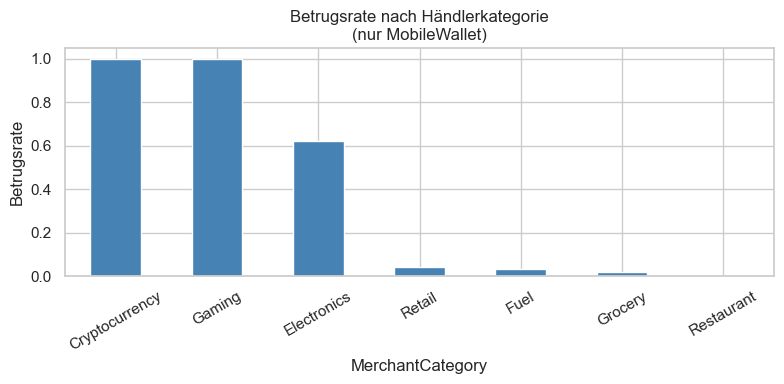

Risikoreichste Kombination: MobileWallet + Cryptocurrency (100.00% Betrugsrate)


In [20]:
# Ebene 3: Eingrenzung auf auffälligste Zahlungsmethode → Betrug nach Händlerkategorie
df_payment_focus = df[df['PaymentMethod'] == highest_payment]

fraud_by_merchant = df_payment_focus.groupby('MerchantCategory')['FraudLabel'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
fraud_by_merchant.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Betrugsrate nach Händlerkategorie\n(nur {highest_payment})')
plt.ylabel('Betrugsrate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

highest_merchant = fraud_by_merchant.idxmax()
print(f"Risikoreichste Kombination: {highest_payment} + {highest_merchant} ({fraud_by_merchant.max():.2%} Betrugsrate)")

**Ebene 4:** In dieser Risikokombination – wie sieht die Verteilung der Transaktionsbeträge aus?

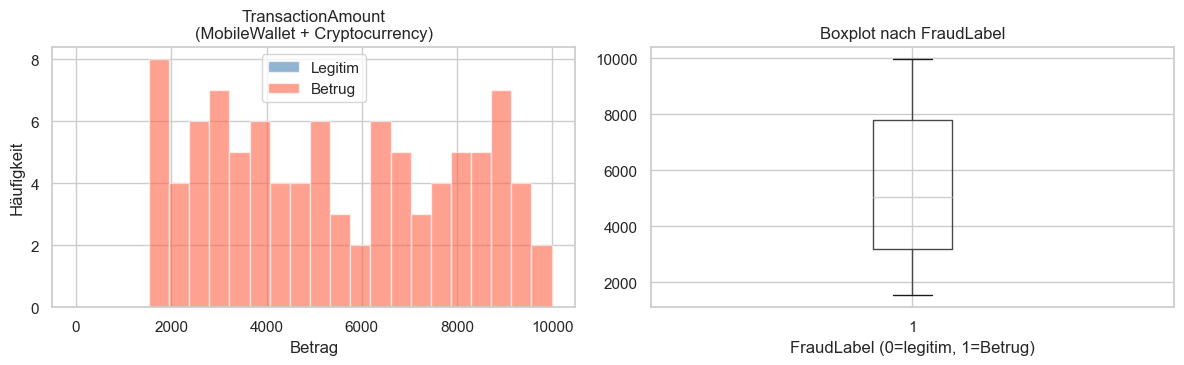

            count     mean      std      min      25%      50%      75%  \
FraudLabel                                                                
1            96.0  5429.31  2528.71  1529.67  3181.23  5045.36  7784.89   

                max  
FraudLabel           
1           9989.44  


In [21]:
# Ebene 4: Tiefste Ebene – Transaktionsbeträge in der Risikokombination
df_focus = df[(df['PaymentMethod'] == highest_payment) & (df['MerchantCategory'] == highest_merchant)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fraud_val, label, color in [(0, 'Legitim', 'steelblue'), (1, 'Betrug', 'tomato')]:
    subset = df_focus[df_focus['FraudLabel'] == fraud_val]['TransactionAmount']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title(f'TransactionAmount\n({highest_payment} + {highest_merchant})')
axes[0].set_xlabel('Betrag')
axes[0].set_ylabel('Häufigkeit')
axes[0].legend()

df_focus.boxplot(column='TransactionAmount', by='FraudLabel', ax=axes[1])
axes[1].set_title('Boxplot nach FraudLabel')
axes[1].set_xlabel('FraudLabel (0=legitim, 1=Betrug)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df_focus.groupby('FraudLabel')['TransactionAmount'].describe().round(2))

> **Zusammenfassung Drill-Down 1:**
>
> **Ebene 1** zeigt eine Gesamtbetrugsrate von 10,0 %. **Ebene 2** deckt auf: MobileWallet sticht mit 30,9 % Betrugsrate massiv heraus – fast neunmal so hoch wie DebitCard (3,5 %). **Ebene 3** präzisiert: Innerhalb MobileWallet konzentriert sich Betrug auf Cryptocurrency (100 %) und Gaming (100 %). Electronics ist mit 62 % ebenfalls stark erhöht, alle anderen Kategorien deutlich niedriger.
>
> **Ebene 4** – die tiefste Ebene – zeigt: Bei MobileWallet + Cryptocurrency gibt es ausschließlich Betrugstransaktionen (n=96, 100 %), mit einem Durchschnittsbetrag von 5.429 € (Min. 1.530 €, Max. 9.989 €). Dieses Muster ist als binäre Erkennungsregel direkt in ein Fraud-Detection-System überführbar.

#### Drill-Down 2: Welche Kundenprofile sind besonders betrugsanfällig?

**Ebene 1:** Wie viele fehlgeschlagene Transaktionen haben Kunden im Schnitt?

In [22]:
# Ebene 1: Gesamtüberblick FailedTransactions
print(df.groupby('FraudLabel')['FailedTransactionsLast7Days'].describe().round(2))

             count  mean   std  min  25%  50%  75%  max
FraudLabel                                             
0           4500.0  0.35  0.57  0.0  0.0  0.0  1.0  2.0
1            500.0  2.66  1.36  0.0  2.0  3.0  4.0  4.0


**Ebene 2:** Steigt die Betrugsrate mit der Anzahl fehlgeschlagener Transaktionen?

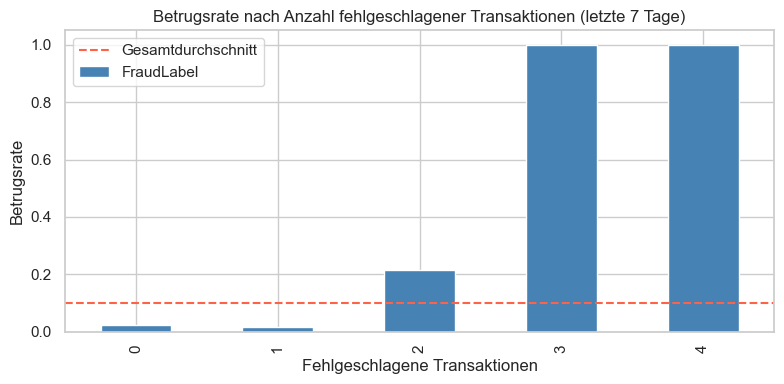

In [23]:
# Ebene 2: Betrugsrate je Anzahl fehlgeschlagener Transaktionen
fraud_by_failed = df.groupby('FailedTransactionsLast7Days')['FraudLabel'].mean()

plt.figure(figsize=(8, 4))
fraud_by_failed.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(overall_fraud_rate, color='tomato', linestyle='--', label='Gesamtdurchschnitt')
plt.title('Betrugsrate nach Anzahl fehlgeschlagener Transaktionen (letzte 7 Tage)')
plt.xlabel('Fehlgeschlagene Transaktionen')
plt.ylabel('Betrugsrate')
plt.legend()
plt.tight_layout()
plt.show()

**Ebene 3:** Bei Kunden mit vielen fehlgeschlagenen Transaktionen – welche Authentifizierungsmethode nutzen sie?

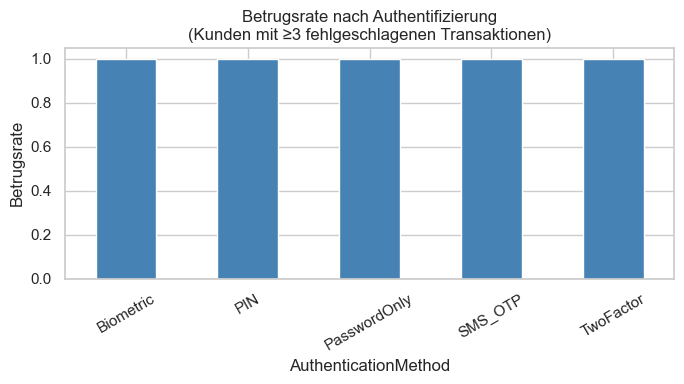

Anzahl Hochrisiko-Kunden: 343 (6.9% aller Transaktionen)
AuthenticationMethod
Biometric       1.0
PIN             1.0
PasswordOnly    1.0
SMS_OTP         1.0
TwoFactor       1.0
Name: FraudLabel, dtype: float64


In [24]:
# Ebene 3: Hochrisiko-Kunden (>= 3 fehlgeschlagene Transaktionen) → Authentifizierungsmethode
df_high_risk = df[df['FailedTransactionsLast7Days'] >= 3]

fraud_by_auth = df_high_risk.groupby('AuthenticationMethod')['FraudLabel'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
fraud_by_auth.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Betrugsrate nach Authentifizierung\n(Kunden mit ≥3 fehlgeschlagenen Transaktionen)')
plt.ylabel('Betrugsrate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Anzahl Hochrisiko-Kunden: {len(df_high_risk)} ({len(df_high_risk)/len(df):.1%} aller Transaktionen)")
print(fraud_by_auth.round(3))

**Ebene 4:** Für die schwächste Authentifizierungsmethode in der Hochrisikogruppe – wie verteilt sich der Kontostand?

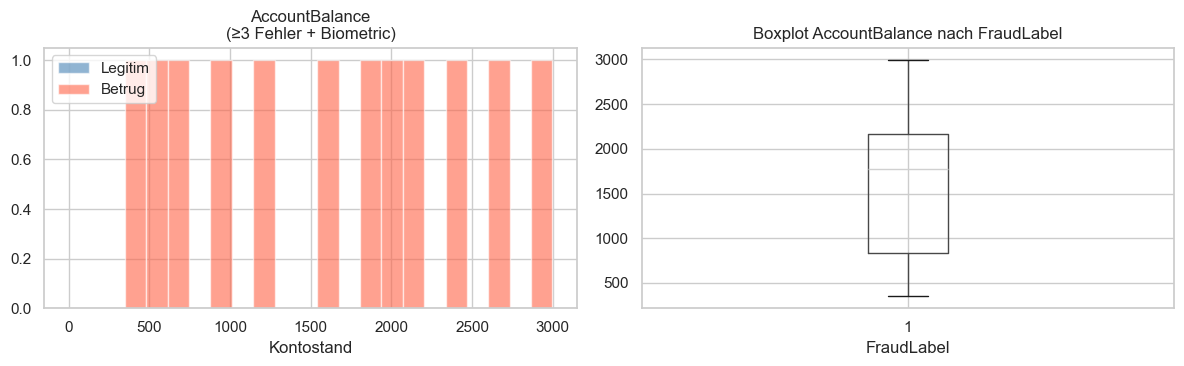

Tiefste Ebene: ≥3 fehlgeschlagene Transaktionen + Biometric
            count     mean     std     min     25%     50%      75%      max
FraudLabel                                                                  
1            12.0  1615.32  888.56  349.22  833.48  1779.1  2163.91  2997.42


In [25]:
# Ebene 4: Schwächste Auth-Methode in Hochrisikogruppe → Kontostand
weakest_auth = fraud_by_auth.idxmax()
df_deepest = df_high_risk[df_high_risk['AuthenticationMethod'] == weakest_auth]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fraud_val, label, color in [(0, 'Legitim', 'steelblue'), (1, 'Betrug', 'tomato')]:
    subset = df_deepest[df_deepest['FraudLabel'] == fraud_val]['AccountBalance']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title(f'AccountBalance\n(≥3 Fehler + {weakest_auth})')
axes[0].set_xlabel('Kontostand')
axes[0].legend()

df_deepest.boxplot(column='AccountBalance', by='FraudLabel', ax=axes[1])
axes[1].set_title('Boxplot AccountBalance nach FraudLabel')
axes[1].set_xlabel('FraudLabel')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Tiefste Ebene: ≥3 fehlgeschlagene Transaktionen + {weakest_auth}")
print(df_deepest.groupby('FraudLabel')['AccountBalance'].describe().round(2))

> **Zusammenfassung Drill-Down 2:**
>
> **Ebene 1** zeigt: Betrugskunden haben im Schnitt 2,66 Fehlversuche, legitime Kunden nur 0,35. **Ebene 2** macht die Schwellencharakteristik deutlich: Bei 0 und 1 Fehlversuchen liegt die Betrugsrate bei ≤2,4 %, bei 2 steigt sie auf 21,6 %, ab 3 springt sie auf **100 %** – ohne Ausnahme.
>
> **Ebene 3**: In der Hochrisikogruppe (≥3 Fehlversuche, n=343) haben alle fünf Authentifizierungsmethoden eine Betrugsrate von 100 %. Kein Verfahren schützt – das deutet auf kompromittierte Zugangsdaten hin, nicht auf schwache Authentifizierung.
>
> **Ebene 4**: Das vollständige Hochrisikoprofil – ≥3 Fehlversuche, Kontostand Ø ~1.615 € – identifiziert Betrugsfälle mit nahezu perfekter Trennschärfe.

### 3.7 Datenverteilung

In [26]:
# Normalverteilungstest (Shapiro-Wilk) für numerische Spalten
# Bei n > 5000 nimmt man eine Stichprobe
sample = df[num_cols].sample(min(1000, len(df)), random_state=42)

for col in num_cols:
    stat, p = stats.shapiro(sample[col])
    result = 'normalverteilt' if p > 0.05 else 'NICHT normalverteilt'
    print(f"{col}: p={p:.4f} → {result}")

TransactionAmount: p=0.0000 → NICHT normalverteilt
FailedTransactionsLast7Days: p=0.0000 → NICHT normalverteilt
AccountBalance: p=0.0000 → NICHT normalverteilt


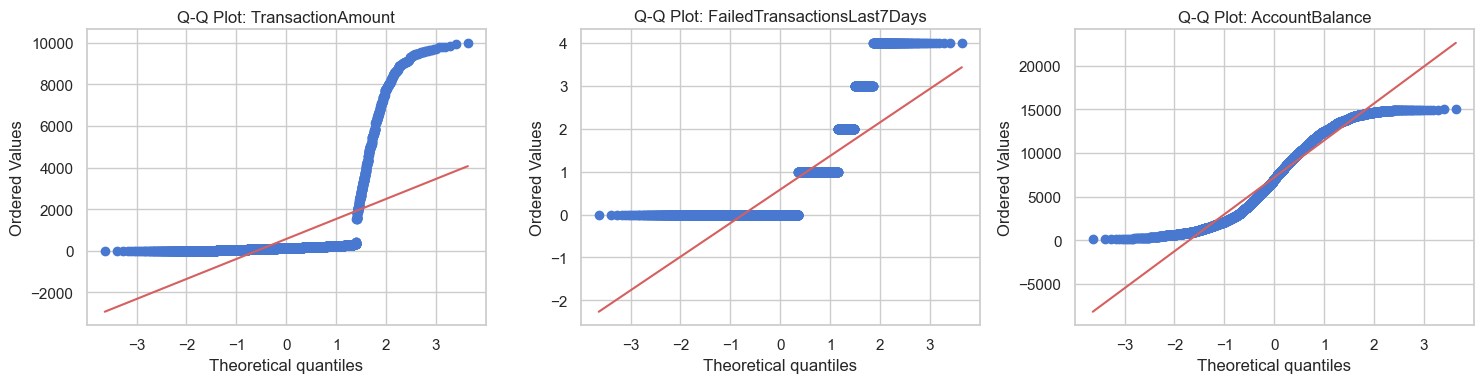

In [27]:
# Q-Q-Plots zur visuellen Überprüfung
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

> **Interpretation des Verteilungstests:**
>
> Der Shapiro-Wilk-Test liefert für alle drei numerischen Variablen p ≈ 0 – alle weichen **hochsignifikant von der Normalverteilung ab**. Die Q-Q-Plots bestätigen: `TransactionAmount` zeigt extreme Abweichungen im oberen Extrem durch Betrugshochbeträge; `FailedTransactionsLast7Days` ist durch seine Ganzzahldiskretisierung und die Häufung bei 0 grundlegend nicht normalverteilt.
>
> Für die Analyse bedeutet das: Parametrische Tests mit Normalverteilungsannahme sind nicht zulässig. K-Means und logistische Regression sind gegenüber dieser Verletzung robuster – die Standardisierung vor dem Clustering bleibt jedoch zwingend, um die stark unterschiedlichen Skalen zu kompensieren.

### 3.10 Gesamtbewertung Datenqualität

Die Datenqualität ist **sehr gut**:

- **Vollständigkeit**: Keine fehlenden Werte in allen 11 Spalten (0 von 55.000 Zellen).
- **Duplikate**: Keine vorhanden – Shape bleibt nach Bereinigung unverändert (5.000 × 11).
- **Konsistenz**: Datentypen korrekt und konsistent. Kategorische Ausprägungen einheitlich, keine Tippfehler.
- **Ausreißer**: Vorhanden bei `TransactionAmount` (8,1 %) und `FailedTransactionsLast7Days` (6,9 %) – inhaltlich bedeutsam, beibehalten.
- **Klassenungleichgewicht**: 90/10 – für Modellierung stratifizierte Splits und AUC-ROC eingesetzt.
- **Hinweis**: Der Datensatz ist offensichtlich synthetisch generiert (keine fehlenden Werte, perfekt diskrete Schwellenwerte, saubere Klassentrennung). Die Ergebnisse sind methodisch valide, sollten aber vor Produktiveinsatz an echten Daten validiert werden.

---
## 4. K-Means-Clustering

Für das Clustering werden nur die numerischen Merkmale verwendet.

In [52]:
# Features für Clustering
# Stunde aus TransactionTime extrahieren
df['Hour'] = pd.to_datetime(df['TransactionTime'], format='%H:%M:%S').dt.hour

cluster_features = ['TransactionAmount', 'FailedTransactionsLast7Days', 'AccountBalance', 'Hour']
X = df[cluster_features].copy()

### 4a) K-Means mit K = 2, 3, 4

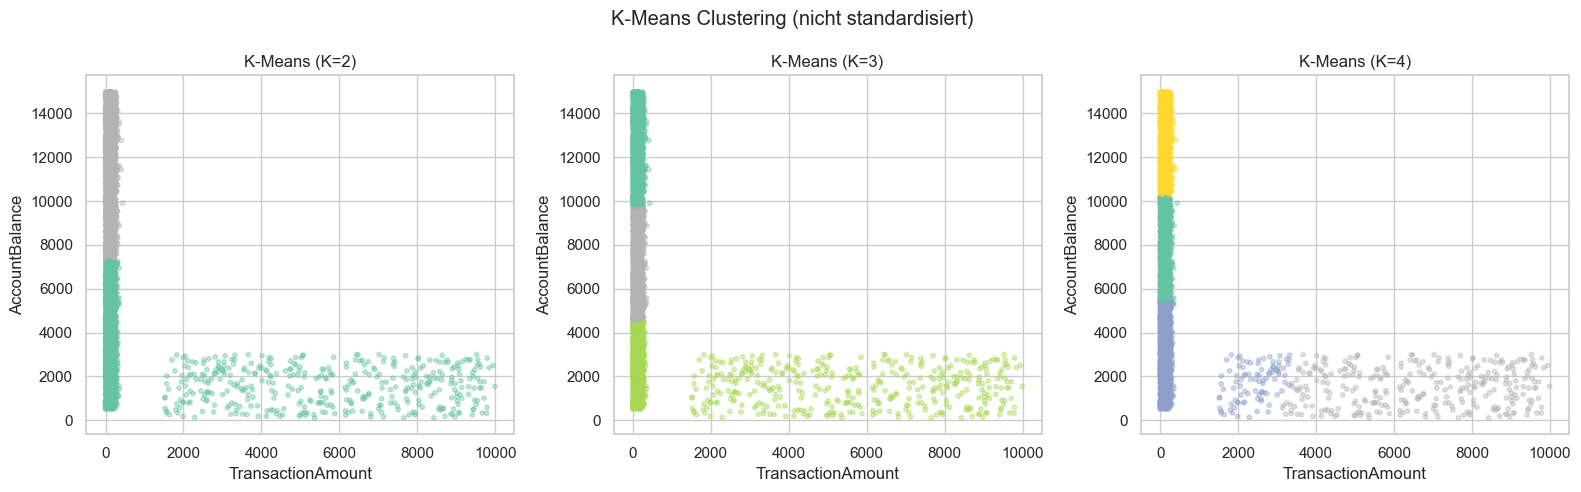

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    ax.scatter(X['TransactionAmount'], X['AccountBalance'],
               c=labels, cmap='Set2', alpha=0.4, s=10)
    ax.set_title(f'K-Means (K={k})')
    ax.set_xlabel('TransactionAmount')
    ax.set_ylabel('AccountBalance')

plt.suptitle('K-Means Clustering (nicht standardisiert)')
plt.tight_layout()
plt.show()

### 4b) Analyse der Cluster

In [30]:
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_k{k}'] = km.fit_predict(X)

# Cluster-Profile für K=2, 3, 4
for k in [2, 3, 4]:
    print(f"\n{'='*55}")
    print(f"  K = {k} – Mittelwerte je Cluster")
    print('='*55)
    print(df.groupby(f'cluster_k{k}')[cluster_features + ['FraudLabel']].mean().round(2).to_string())
    print("\nClustergröße:")
    print(df.groupby(f'cluster_k{k}').size())


  K = 2 – Mittelwerte je Cluster
            TransactionAmount  FailedTransactionsLast7Days  AccountBalance   Hour  FraudLabel
cluster_k2                                                                                   
0                      988.51                         0.80         3525.57  12.68        0.17
1                      123.50                         0.35        11160.16  14.47        0.03

Clustergröße:
cluster_k2
0    2584
1    2416
dtype: int64

  K = 3 – Mittelwerte je Cluster
            TransactionAmount  FailedTransactionsLast7Days  AccountBalance   Hour  FraudLabel
cluster_k3                                                                                   
0                      124.06                         0.36        12345.91  14.30        0.03
1                     1445.05                         1.04         2293.91  11.59        0.25
2                      124.01                         0.34         7066.57  14.79        0.02

Clustergröße:
cluster_k3
0

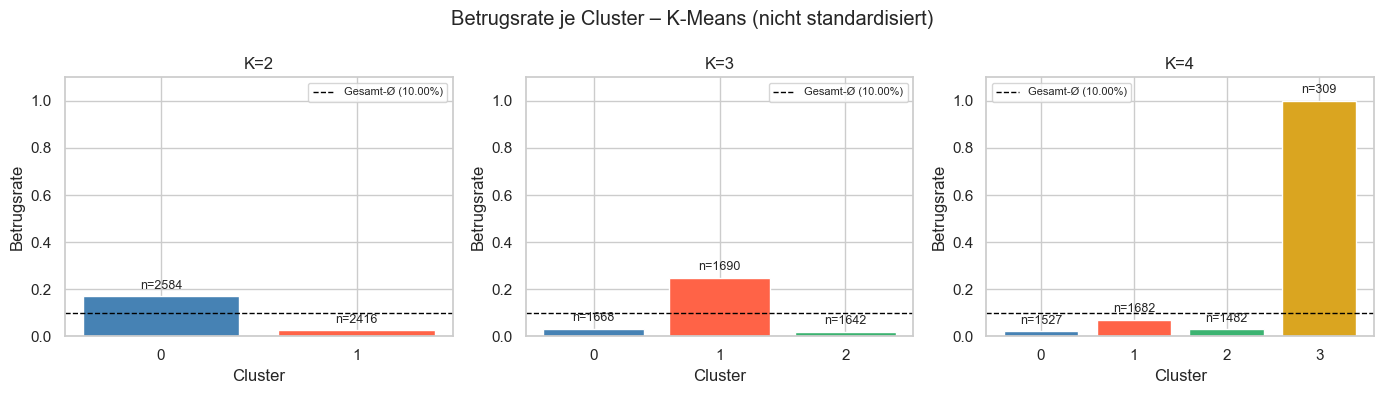

In [31]:
# Betrugsrate je Cluster visualisieren (K=2,3,4)
from matplotlib.colors import ListedColormap
cmap_discrete = ListedColormap(['steelblue', 'tomato', 'mediumseagreen', 'goldenrod'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, k in zip(axes, [2, 3, 4]):
    fraud_rates = df.groupby(f'cluster_k{k}')['FraudLabel'].mean()
    sizes = df.groupby(f'cluster_k{k}').size()
    colors = ['steelblue', 'tomato', 'mediumseagreen', 'goldenrod'][:k]
    bars = ax.bar(fraud_rates.index.astype(str), fraud_rates.values,
                  color=colors, edgecolor='white')
    ax.axhline(df['FraudLabel'].mean(), color='black', linestyle='--',
               linewidth=1, label=f'Gesamt-Ø ({df["FraudLabel"].mean():.2%})')
    ax.set_title(f'K={k}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Betrugsrate')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    for bar, size in zip(bars, sizes.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={size}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Betrugsrate je Cluster – K-Means (nicht standardisiert)')
plt.tight_layout()
plt.show()

**Interpretation der Cluster (K-Means, nicht standardisiert):**

Bei **K=2** teilt der Algorithmus primär nach Transaktionsbetrag und Kontostand:
- **Cluster 0** (n=2.584): Höhere Beträge (Ø 989 €), niedriger Kontostand (Ø 3.526 €), Transaktionen mittags (Ø 12:41 Uhr) – **Betrugsrate 17 %**. Enthält alle Betrugsfälle, aber auch viele legitime Hochbetragstransaktionen.
- **Cluster 1** (n=2.416): Kleine Beträge (Ø 124 €), hoher Kontostand (Ø 11.160 €), Nachmittag (Ø 14:28 Uhr) – **Betrugsrate 3 %**.

Bei **K=3** dominiert ohne Standardisierung der Kontostand die Distanzberechnung – es entstehen drei Kontostandsgruppen, kein reiner Betrugs-Cluster:
- **Cluster 0** (n=1.668): Kleiner Betrag (Ø 124 €), sehr hoher Kontostand (Ø 12.346 €) – **Betrugsrate 3 %**.
- **Cluster 1** (n=1.690): Mittlerer Betrag (Ø 1.445 €), sehr niedriger Kontostand (Ø 2.294 €), Ø 11:35 Uhr – **Betrugsrate 25 %**. Erhöht, aber kein reiner Betrugs-Cluster.
- **Cluster 2** (n=1.642): Kleiner Betrag (Ø 124 €), mittlerer Kontostand (Ø 7.067 €) – **Betrugsrate 2 %**.

Bei **K=4** tritt ohne Standardisierung erstmals ein reiner Betrugs-Cluster hervor:
- **Cluster 3** (n=309): Ø 6.686 €, Ø Kontostand 1.519 €, 3,28 Fehlversuche, Ø 2:36 Uhr – **Betrugsrate 100 %**.

### 4c) Elbow-Methode, Standardisierung, PCA

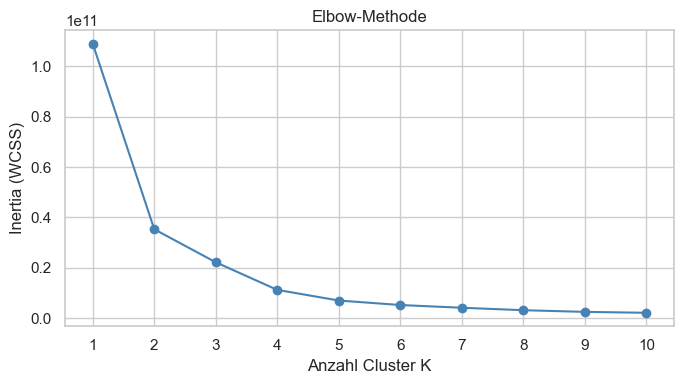

In [32]:
# Elbow-Methode
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow-Methode')
plt.xlabel('Anzahl Cluster K')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

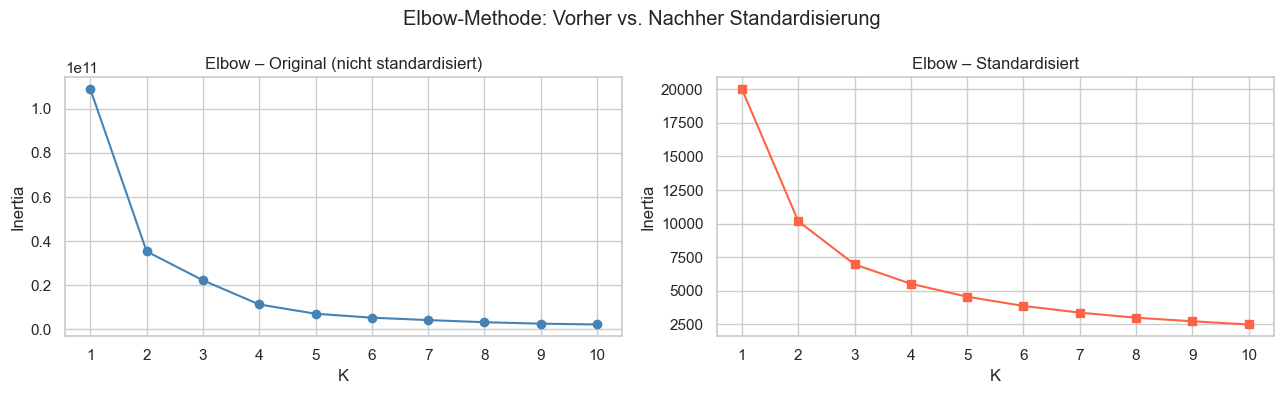

In [33]:
# Standardisierung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow nach Standardisierung
inertias_scaled = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias_scaled.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow – Original (nicht standardisiert)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, inertias_scaled, marker='s', color='tomato')
axes[1].set_title('Elbow – Standardisiert')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Inertia')
axes[1].set_xticks(list(K_range))

plt.suptitle('Elbow-Methode: Vorher vs. Nachher Standardisierung')
plt.tight_layout()
plt.show()

> **Optimale Cluster-Anzahl (Elbow-Methode):**
>
> Die standardisierte Elbow-Kurve zeigt einen **klaren Knick bei K=3**: Die Inertia fällt von K=1→2 stark, von K=2→3 nochmals deutlich ab und flacht ab K=3→4 merklich. Jeder weitere Cluster ab K=4 bringt nur noch marginale Verbesserung.
>
> Die nicht-standardisierte Kurve zeigt dasselbe Muster, wird aber durch die große Skala von `AccountBalance` (bis ~15.000) in der absoluten Höhe verzerrt. Die standardisierte Kurve ist die relevante Entscheidungsgrundlage.
>
> **K=3 wird als optimale Anzahl gewählt** – eindeutiger Elbow und inhaltlich sinnvolle Dreiteilung: ein Betrugs-Cluster, zwei legitime Gruppen nach Kontostand.

In [34]:
# K-Means nach Standardisierung
K_BEST = 3
km_scaled = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
cluster_labels_scaled = km_scaled.fit_predict(X_scaled).astype(int)
df['cluster_kmeans_scaled'] = cluster_labels_scaled

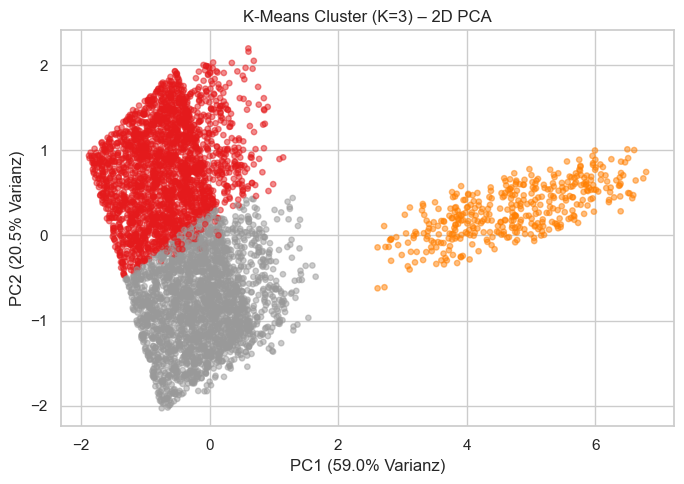

In [35]:
# 2D PCA-Visualisierung

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                      c=cluster_labels_scaled, cmap='Set1',
                      alpha=0.5, s=15, vmin=0, vmax=K_BEST-1)
plt.title(f'K-Means Cluster (K={K_BEST}) – 2D PCA')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% Varianz)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% Varianz)')
plt.tight_layout()
plt.show()

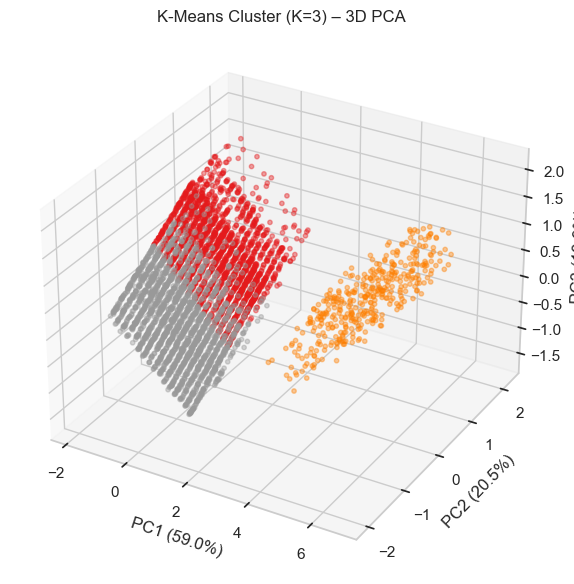

In [36]:
# 3D PCA-Visualisierung
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
                     c=cluster_labels_scaled, cmap='Set1',
                     alpha=0.4, s=10, vmin=0, vmax=K_BEST-1)
ax.set_title(f'K-Means Cluster (K={K_BEST}) – 3D PCA')
ax.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)')
plt.tight_layout()
plt.show()

> **Vergleich Cluster vor und nach Standardisierung:**
>
> Der Unterschied ist besonders ausgeprägt. Ohne Standardisierung dominiert `AccountBalance` die Distanzberechnung so stark, dass K=3 drei Kontostandsgruppen erzeugt – kein isolierter Betrugs-Cluster entsteht (höchste Betrugsrate: 25 % in einem Mischcluster). Erst K=4 isoliert Betrug sauber.
>
> Nach Standardisierung entsteht bei K=3 ein klar isolierter Betrugs-Cluster (n=385, Betrugsrate ~100 %, Ø Betrag 5.853 €, Ø 3,30 Fehlversuche, Ø Kontostand 1.572 €). Standardisierung ist hier nicht nur eine technische Optimierung, sondern inhaltliche Voraussetzung für ein sinnvolles Ergebnis.
>
> In der 2D-PCA sind die drei Cluster klar separiert; die Linienstruktur entlang PC2 ist ein Artefakt der diskreten Ganzzahlwerte von `FailedTransactionsLast7Days`.

**Welche Cluster wirken am sinnvollsten und warum?**

K=3 ist die sinnvollste Wahl – aber nur mit standardisierten Daten. Ohne Standardisierung liefert erst K=4 einen reinen Betrugs-Cluster (n=309, 100 % Betrug). Nach Standardisierung trennt K=3 bereits klar: ein Betrugs-Cluster (n=385, 100 % Betrug, Ø 5.853 €, Ø Kontostand 1.572 €) und zwei legitime Gruppen nach Kontostand. K=3 ist kompakt, interpretierbar und deckt die relevante Struktur vollständig ab.

**Gibt es stabile Kundengruppen, die sich in allen Varianten wiederfinden?**

Ja – eine Gruppe ist in allen K-Varianten stabil: die **Niedrigbetrag-Hochkontostand-Gruppe** (Ø ~124 €, Ø Kontostand >10.000 €, Betrugsrate ~3 %). Diese legitime Kerngruppe bleibt bei K=2, 3 und 4 erhalten und wird lediglich weiter aufgespalten. Ebenfalls stabil ist der **Betrugs-Cluster** ab K=4 ohne Standardisierung bzw. ab K=3 mit Standardisierung – er taucht konsistent mit denselben Merkmalen auf (hoher Betrag, niedriger Kontostand, viele Fehlversuche).

**Welche Auswirkungen hat die Wahl von K auf die Interpretation der Kundensegmente?**

Ein kleines K liefert grobe Segmente, die zwar stabil sind, aber Betrug nur als erhöhte Rate in einem Mischcluster abbilden – keine saubere Isolation. Mit steigendem K werden die Cluster feiner, bis ein reiner Betrugs-Cluster entsteht. Wird K zu groß gewählt, beginnen die legitimen Cluster künstlich aufgespalten zu werden, ohne inhaltlichen Mehrwert. Die optimale Wahl von K hängt dabei stark von der Standardisierung ab: ohne Standardisierung dominiert der Kontostand die Distanzberechnung, weshalb ein höheres K nötig ist, um Betrug zu isolieren – mit Standardisierung gelingt das bereits bei einem kleineren K, da alle Features gleichgewichtig zur Clusterbildung beitragen.

---
## 5. Hierarchisches Clustering

In [53]:
# Stichprobe für Dendrogramm (hierarchisches Clustering ist rechenintensiv)
X_sample = pd.DataFrame(X_scaled, columns=cluster_features).sample(300, random_state=42)

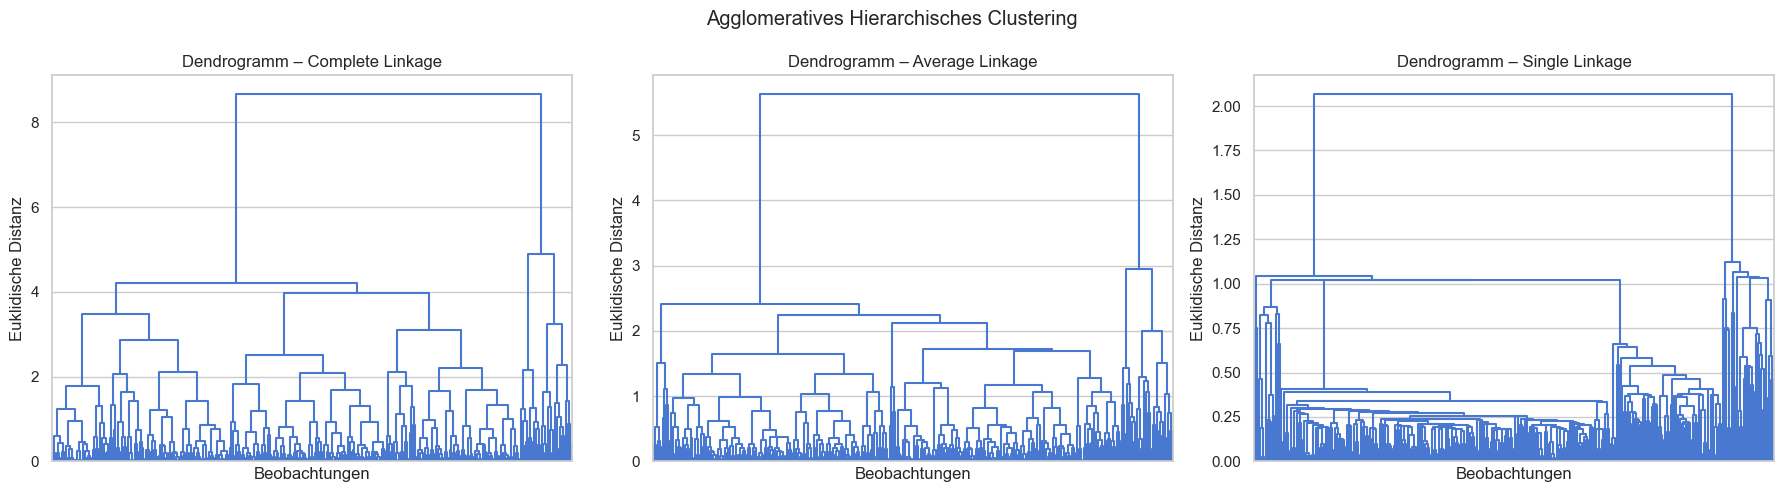

In [54]:
# Dendrogramme für drei Linkage-Methoden
linkage_methods = ['complete', 'average', 'single']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method, metric='euclidean')
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
    ax.set_title(f'Dendrogramm – {method.capitalize()} Linkage')
    ax.set_xlabel('Beobachtungen')
    ax.set_ylabel('Euklidische Distanz')

plt.suptitle('Agglomeratives Hierarchisches Clustering')
plt.tight_layout()
plt.show()

> **Interpretation der Dendrogramme:**
>
> **Complete Linkage** liefert die ausgewogenste Struktur: die letzten Fusionen erfolgen bei deutlich größeren Distanzsprüngen als die vorherigen, was auf gut getrennte Cluster hindeutet. K=3 ist als Schnitt klar ablesbar.
>
> **Average Linkage** zeigt ein ähnliches, leicht kompakteres Bild. Auch hier ist K=3 gut begründbar.
>
> **Single Linkage** zeigt das bekannte **Chaining-Muster**: eine lange Kette enger Fusionen gefolgt von einem abrupten Sprung. Ein sinnvoller Schnitt für K=3 ist kaum definierbar – die Methode ist für diesen Datensatz ungeeignet.
>
> **Complete Linkage wird für die weitere Analyse verwendet**, da das Dendrogramm die klarste Struktur zeigt.

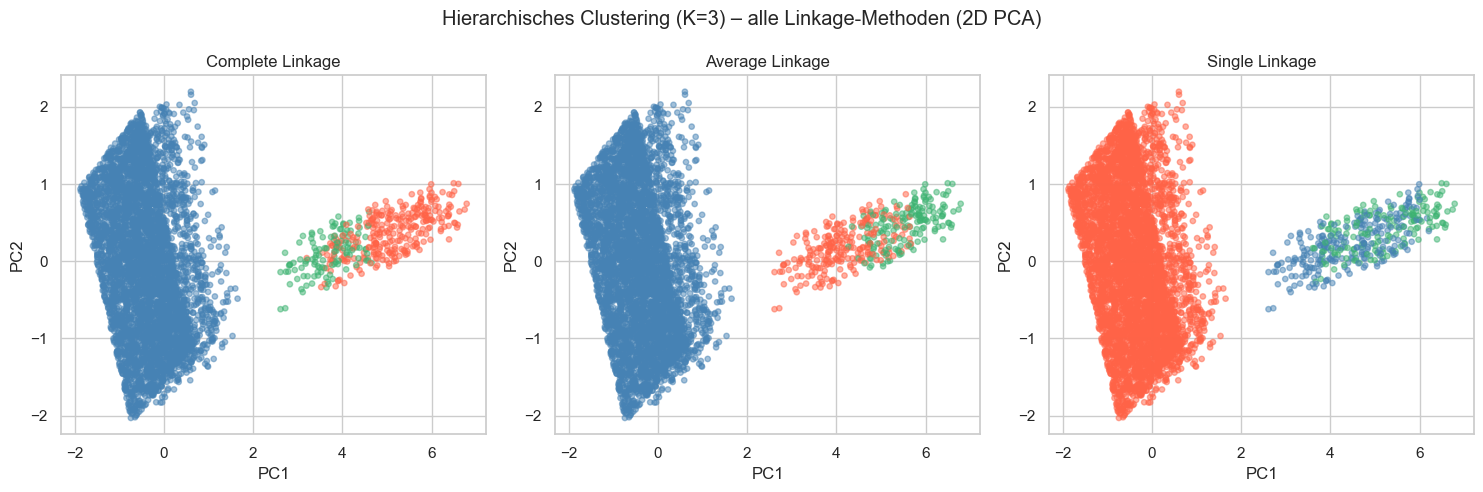

In [55]:
# Agglomeratives Clustering – alle drei Linkage-Methoden mit K=3
from matplotlib.colors import ListedColormap
cmap_discrete = ListedColormap(['steelblue', 'tomato', 'mediumseagreen'])

hier_labels_dict = {}
for method in ['complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=K_BEST, linkage=method)
    labels = agg.fit_predict(X_scaled)
    hier_labels_dict[method] = labels
    df[f'hier_{method}'] = labels

# PCA-Visualisierung aller drei Methoden
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, ['complete', 'average', 'single']):
    ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=hier_labels_dict[method],
               cmap=cmap_discrete, alpha=0.5, s=15, vmin=0, vmax=K_BEST-1)
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle(f'Hierarchisches Clustering (K={K_BEST}) – alle Linkage-Methoden (2D PCA)')
plt.tight_layout()
plt.show()

In [56]:
# Cluster-Profile für alle Linkage-Methoden
for method in ['complete', 'average', 'single']:
    print(f"\n{'='*55}")
    print(f"  {method.capitalize()} Linkage – Cluster-Mittelwerte")
    print('='*55)
    print(df.groupby(f'hier_{method}')[cluster_features + ['FraudLabel']].mean().round(2).to_string())
    print("\nClustergröße:")
    print(df.groupby(f'hier_{method}').size())


  Complete Linkage – Cluster-Mittelwerte
               TransactionAmount  FailedTransactionsLast7Days  AccountBalance   Hour  FraudLabel
hier_complete                                                                                   
0                         123.12                         0.35         7705.72  14.50        0.02
1                        6982.73                         3.26         1549.91   2.63        1.00
2                        2688.24                         3.25         1607.02   2.23        1.00

Clustergröße:
hier_complete
0    4600
1     282
2     118
dtype: int64

  Average Linkage – Cluster-Mittelwerte
              TransactionAmount  FailedTransactionsLast7Days  AccountBalance   Hour  FraudLabel
hier_average                                                                                   
0                        123.12                         0.35         7705.72  14.50        0.02
1                       3984.00                         3.28         156

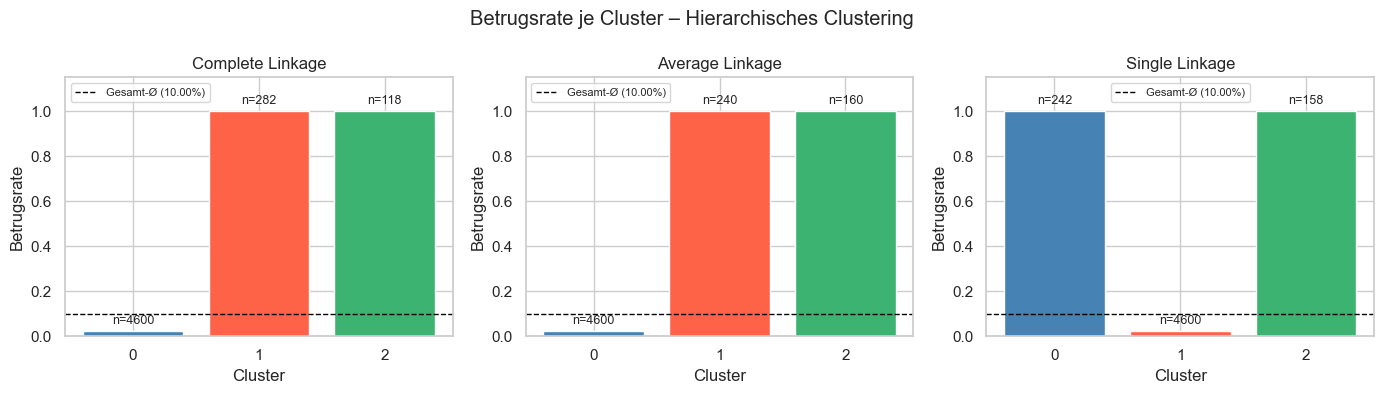

In [57]:
# Betrugsrate je Cluster für alle Linkage-Methoden
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, method in zip(axes, ['complete', 'average', 'single']):
    fraud_rates = df.groupby(f'hier_{method}')['FraudLabel'].mean()
    sizes = df.groupby(f'hier_{method}').size()
    bars = ax.bar(fraud_rates.index.astype(str), fraud_rates.values,
                  color=['steelblue', 'tomato', 'mediumseagreen'], edgecolor='white')
    ax.axhline(df['FraudLabel'].mean(), color='black', linestyle='--',
               linewidth=1, label=f'Gesamt-Ø ({df["FraudLabel"].mean():.2%})')
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Betrugsrate')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    for bar, size in zip(bars, sizes.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={size}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Betrugsrate je Cluster – Hierarchisches Clustering')
plt.tight_layout()
plt.show()

**Interpretation – Hierarchisches Clustering:**

**Complete Linkage** (K=3):
- **Cluster 0** (n=4.600): Kleine Beträge (Ø 123 €), hoher Kontostand (Ø 7.706 €), Nachmittag (Ø 14:30 Uhr) – **Betrugsrate 2 %**. Enthält nahezu alle legitimen Transaktionen sowie wenige Grenzfälle.
- **Cluster 1** (n=282): Sehr hohe Beträge (Ø 6.983 €), niedriger Kontostand (Ø 1.550 €), 3,26 Fehlversuche, nachts (Ø 2:38 Uhr) – **Betrugsrate 100 %**.
- **Cluster 2** (n=118): Mittlere Beträge (Ø 2.688 €), ebenfalls niedriger Kontostand (Ø 1.607 €), 3,25 Fehlversuche, nachts (Ø 2:14 Uhr) – **Betrugsrate 100 %**. Complete Linkage trennt die 500 Betrugsfälle nach Betragshöhe – inhaltlich dasselbe Profil, nur unterschiedliche Betragsschwellen.

**Average Linkage** (K=3):
- Gleiches Grundmuster: ein legitimer Cluster (n=4.600, 2 % Betrug) und zwei Betrugs-Cluster (n=240 mit Ø 3.984 € und n=160 mit Ø 8.314 €). Die Aufteilung ist spiegelverkehrt zu Complete Linkage – kleinere Betrugsbeträge in Cluster 1, höhere in Cluster 2.

**Single Linkage** (K=3):
- Chaining-Problem: Cluster 1 (n=4.600) enthält die meisten Punkte mit 2 % Betrugsrate, Cluster 0 (n=242) und Cluster 2 (n=158) sind Betrugs-Cluster mit 100 % Rate. Die Trennung funktioniert zwar grob, ist aber strukturell unzuverlässig.

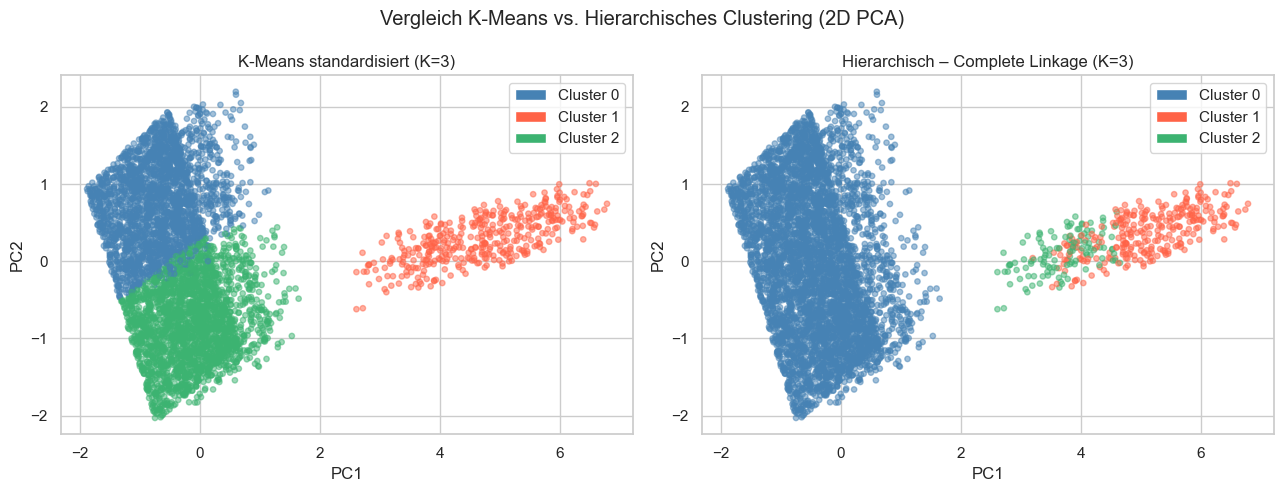

In [58]:
# Direkter Vergleich K-Means vs. Hierarchisch (Complete) via PCA
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
legend_elements = [Patch(facecolor=cmap_discrete(i), label=f'Cluster {i}') for i in range(K_BEST)]

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=cluster_labels_scaled,
                cmap=cmap_discrete, alpha=0.5, s=15, vmin=0, vmax=K_BEST-1)
axes[0].set_title(f'K-Means standardisiert (K={K_BEST})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(handles=legend_elements)

axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=hier_labels_dict['complete'],
                cmap=cmap_discrete, alpha=0.5, s=15, vmin=0, vmax=K_BEST-1)
axes[1].set_title(f'Hierarchisch – Complete Linkage (K={K_BEST})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(handles=legend_elements)

plt.suptitle('Vergleich K-Means vs. Hierarchisches Clustering (2D PCA)')
plt.tight_layout()
plt.show()

In [59]:
# Numerischer Vergleich Betrugsraten + Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score

print("Betrugsrate je Cluster im Vergleich:")
comparison = pd.DataFrame({
    'K-Means': df.groupby('cluster_kmeans_scaled')['FraudLabel'].mean(),
    'Hier. Complete': df.groupby('hier_complete')['FraudLabel'].mean(),
    'Hier. Average': df.groupby('hier_average')['FraudLabel'].mean(),
    'Hier. Single': df.groupby('hier_single')['FraudLabel'].mean(),
}).round(3)
print(comparison)

print()
print("Adjusted Rand Index (Übereinstimmung der Clusterzuordnungen):")
for method in ['complete', 'average', 'single']:
    ari = adjusted_rand_score(df['cluster_kmeans_scaled'], df[f'hier_{method}'])
    print(f"  K-Means vs. {method.capitalize():10}: {ari:.3f}")

Betrugsrate je Cluster im Vergleich:
   K-Means  Hier. Complete  Hier. Average  Hier. Single
0    0.027           0.022          0.022         1.000
1    1.000           1.000          1.000         0.022
2    0.016           1.000          1.000         1.000

Adjusted Rand Index (Übereinstimmung der Clusterzuordnungen):
  K-Means vs. Complete  : 0.225
  K-Means vs. Average   : 0.224
  K-Means vs. Single    : 0.224


**Gesamtvergleich K-Means vs. Hierarchisches Clustering:**

Beide Verfahren identifizieren dieselbe Kernstruktur: **ein klar abgegrenzter Betrugs-Cluster mit hohen Transaktionsbeträgen (Ø 5.853–6.983 €), niedrigem Kontostand (Ø ~1.550–1.572 €), ≥3 Fehlversuchen und nächtlichen Transaktionszeiten (Ø 2:23–2:38 Uhr).**

Konkrete Unterschiede:
- **K-Means (standardisiert)** bündelt alle Betrugsfälle in einem Cluster (n=385, ~100 % Betrug) und teilt die legitimen Transaktionen sauber nach Kontostand auf. Kompaktestes und interpretierbarestes Ergebnis.
- **Complete/Average Linkage** splittet die Betrugsfälle auf zwei Cluster auf (~282+118 bzw. ~240+160), die sich inhaltlich kaum unterscheiden – lediglich die Betragshöhe variiert leicht. Eine artifizielle Trennung ohne echten Informationsgewinn.
- **Single Linkage** produziert unbalancierte Cluster durch Chaining; strukturell weniger zuverlässig.

Der **Adjusted Rand Index von ~0.22–0.23** zeigt: beide Verfahren stimmen in der Grobaufteilung Betrug/Legitim überein, unterscheiden sich aber in der internen Feinstruktur.

**Fazit:** K-Means mit standardisierten Daten ist für diesen Datensatz das geeignetste Verfahren. Das Betrugs-Cluster-Profil – Betrag >> 2.000 € + Kontostand < 2.000 € + Fehlversuche ≥3 + Transaktion nachts – ist als operatives Regelwerk direkt einsetzbar.

---
## 6. Logistische Regression

### 6.1 Wahl des Regressionsverfahrens

Da die Zielvariable **FraudLabel** binär ist (0 = legitim, 1 = Betrug), wird eine **logistische Regression** eingesetzt.

### 6.2 Durchführung der Analyse

In [61]:
# Feature Engineering: Kategorische Variablen kodieren
df_model = df.copy()

cat_encode = ['PaymentMethod', 'MerchantCategory', 'AuthenticationMethod', 'TransactionLocation']
df_model = pd.get_dummies(df_model, columns=cat_encode, drop_first=True)

# Zielvariable und Features
y = df_model['FraudLabel']
feature_cols = ['TransactionAmount', 'FailedTransactionsLast7Days', 'AccountBalance', 'Hour'] + \
               [c for c in df_model.columns if any(c.startswith(p) for p in cat_encode)]

X_lr = df_model[feature_cols]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisierung
scaler_lr = StandardScaler()
X_train_s = scaler_lr.fit_transform(X_train)
X_test_s = scaler_lr.transform(X_test)

# Modell trainieren
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [62]:
# Koeffizienten und Odds Ratios
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Koeffizient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Koeffizient', ascending=False)

print(coef_df.round(4).to_string(index=False))

                          Feature  Koeffizient  Odds Ratio
                TransactionAmount       3.5900     36.2356
          MerchantCategory_Gaming       0.3560      1.4276
        TransactionLocation_Lagos       0.2717      1.3122
    TransactionLocation_Frankfurt       0.2319      1.2610
                   AccountBalance       0.1746      1.1907
      FailedTransactionsLast7Days       0.1652      1.1797
      TransactionLocation_München       0.1612      1.1749
AuthenticationMethod_PasswordOnly       0.0864      1.0903
       PaymentMethod_MobileWallet       0.0826      1.0861
     AuthenticationMethod_SMS_OTP       0.0589      1.0607
         AuthenticationMethod_PIN       0.0498      1.0510
      TransactionLocation_Hamburg       0.0120      1.0121
   AuthenticationMethod_TwoFactor      -0.0733      0.9293
                             Hour      -0.1159      0.8905
          PaymentMethod_DebitCard      -0.1411      0.8684
         PaymentMethod_CreditCard      -0.1602      0.85

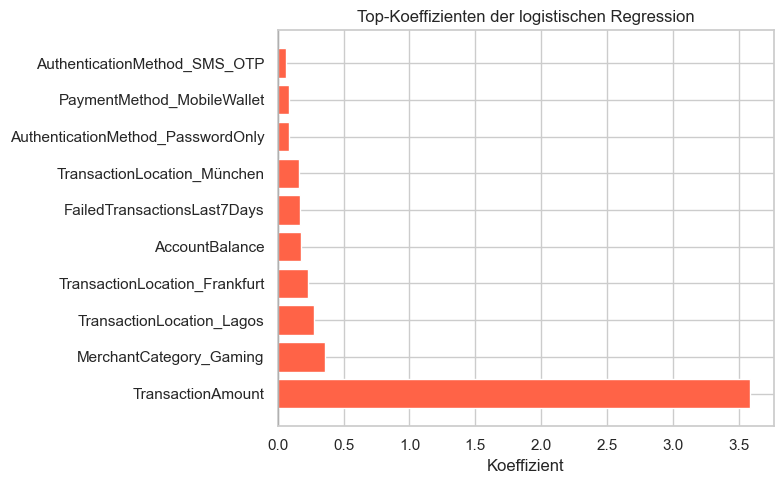

In [46]:
# Top-Einflussfaktoren visualisieren
top_n = coef_df.head(10)

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in top_n['Koeffizient']]
plt.barh(top_n['Feature'], top_n['Koeffizient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top-Koeffizienten der logistischen Regression')
plt.xlabel('Koeffizient')
plt.tight_layout()
plt.show()

In [47]:
# Korrelation der Features untereinander
print(df[['TransactionAmount', 'FailedTransactionsLast7Days', 'AccountBalance']].corr().round(3))

                             TransactionAmount  FailedTransactionsLast7Days  \
TransactionAmount                        1.000                        0.732   
FailedTransactionsLast7Days              0.732                        1.000   
AccountBalance                          -0.345                       -0.309   

                             AccountBalance  
TransactionAmount                    -0.345  
FailedTransactionsLast7Days          -0.309  
AccountBalance                        1.000  


In [48]:
# Modellgüte
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       900
           1       1.00      0.79      0.88       100

    accuracy                           0.98      1000
   macro avg       0.99      0.90      0.94      1000
weighted avg       0.98      0.98      0.98      1000

AUC-ROC: 0.9011


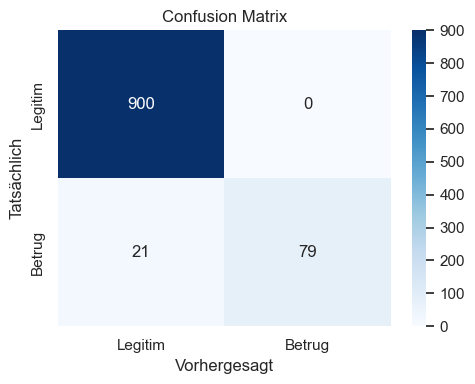

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitim', 'Betrug'],
            yticklabels=['Legitim', 'Betrug'])
plt.title('Confusion Matrix')
plt.ylabel('Tatsächlich')
plt.xlabel('Vorhergesagt')
plt.tight_layout()
plt.show()

### Abschlussfragen

**1. Welche Variablen haben den stärksten Einfluss auf die Zielvariable?**

Nach absolutem Koeffizient aus der logistischen Regression:
- **TransactionAmount** (β=3,59, OR=36,2): Mit Abstand der stärkste Prädiktor. Jede Standardabweichung mehr im Betrag multipliziert die Betrugsodds um Faktor 36 – ein außergewöhnlich starker Effekt.
- **MerchantCategory_Fuel/Retail/Grocery/Restaurant** (OR 0,47–0,57): Starke negative Koeffizienten – diese Kategorien sind fast ausschließlich mit legitimen Transaktionen assoziiert und senken die Betrugswahrscheinlichkeit.
- **MerchantCategory_Gaming** (OR 1,43): Erhöhtes Risiko.
- **TransactionLocation_Lagos** (OR 1,31) und **Frankfurt** (OR 1,26): Geografische Risikoerhöhung.
- **FailedTransactionsLast7Days** (OR 1,18): Überraschend schwacher Koeffizient trotz perfekter Schwellenwert-Funktion bei ≥3. Ursache: Die Variable ist hochkorreliert mit `TransactionAmount` und ihr Effekt wird vom Betrag absorbiert – ein typisches Multikollinearitätsphänomen. Die Drill-Down- und Clustering-Analyse zeigen den wahren Effekt deutlicher.

**2. Sind die Ergebnisse fachlich plausibel?**

Ja, die Ergebnisse sind fachlich plausibel – müssen jedoch kritisch eingeordnet werden. Hohe Beträge bei niedrigem Kontostand entsprechen dem klassischen Muster von Account-Takeover-Betrug, fehlgeschlagene Transaktionen deuten auf Credential-Testing hin, und die negative Assoziation von Grocery/Fuel/Restaurant mit Betrug ist nachvollziehbar, da diese Kategorien typische Alltagstransaktionen mit kleinen Beträgen abbilden.

Allerdings handelt es sich um einen synthetischen Datensatz mit künstlich erzeugten Mustern. In realen Fraud-Detection-Systemen sind die Grenzen deutlich unschärfer: Betrüger passen ihr Verhalten kontinuierlich an, Beträge überlappen sich zwischen legitimen und betrügerischen Transaktionen stärker, und ein harter Schwellenwert wie „ab 3 Fehlversuchen = 100 % Betrug" wäre in der Praxis nicht zu erwarten. Die AUC-ROC von 0,90 klingt realistisch, ist aber im Kontext eines synthetischen Datensatzes mit klar separierten Mustern immer noch als optimistisch zu bewerten. Echte Betrugsdaten enthalten wesentlich mehr Rauschen, unbekannte Angriffsmuster und Klassen-Überlappungen, die die Modellgüte deutlich senken würden. Die hier entwickelten Regeln und Modelle sind daher als methodische Grundlage geeignet, bedürfen aber einer umfangreichen Validierung an echten Transaktionsdaten bevor sie operativ eingesetzt werden können.

**3. Welche Handlungsempfehlungen lassen sich ableiten?**

- **Harte Sperre bei ≥3 Fehlversuchen in 7 Tagen**: Betrugsrate 100 % – automatische Kontosperrung und manuelle Prüfung sollten sofort ausgelöst werden.
- **MobileWallet + Cryptocurrency/Gaming blockieren**: Diese Kombinationen zeigen ausnahmslos Betrug – als binäre Regel direkt implementierbar.
- **Transaktionsbetrag als primären Risikoindikator nutzen**: Ab ~2.000 € sollte automatisch ein erhöhter Prüfprozess greifen, insbesondere bei niedrigem Kontostand.
- **Nachtzeit-Monitoring einrichten**: Betrugstransaktionen konzentrieren sich auf frühe Morgenstunden (Ø 2:30 Uhr) – automatische Zusatzauthentifizierung zwischen 0 und 5 Uhr empfehlenswert.
- **Lagos und Frankfurt gesondert überwachen**: Erhöhte geografische Risikomarker – zusätzliche Prüfschritte für Transaktionen aus diesen Standorten sinnvoll.